# 🔍 Grid Search — Arabic CV Analyzer

### 🔬 التشخيص من نتائج التشغيل السابق:
```
ضعيف : f1=0.89  ✅
متوسط: f1=0.41  ❌ ضعيف جداً
جيد  : f1=0.66  ⚠️  (recall=1.00 لكن precision=0.49)
ممتاز: f1=0.84  ✅
```

**السبب:** `balance_dataset_v2.py` كان بيزوّد الفئات الناقصة لحد target=400 بس، لكن
فئة "ممتاز" كانت أصلاً 1805 (أكبر بكتير من الباقي) فالداتا فضلت غير متوازنة:
```
ضعيف :  323 (12.5%)
متوسط:  500 (19.3%)
جيد  :  324 (12.5%)
ممتاز: 1443 (55.7%)  ← لسه مهيمنة
```

### ✅ الحل المتبع هنا (بدون تقليل أي داتا):
- استخدم `balance_dataset_v3.py` (مرفق) عشان يزوّد كل الفئات الناقصة لحد ما توصل
  لنفس عدد الفئة المهيمنة (ممتاز)، بدل ما نقلل من ممتاز
- باقي تحسينات v2 لسه موجودة: Weighted Regression Loss + Cosine Scheduler

| Param | Values | السبب |
|-------|--------|-------|
| `lr` | [5e-6, 1e-5, 2e-5, 3e-5] | الأكثر تأثيراً على الـ BERT |
| `dropout` | [0.1, 0.2, 0.3] | يتحكم في الـ overfitting |
| `aux_weight` | [0.1, 0.3, 0.5] | نسبة الـ classification loss |

**الباقي ثابت:** `batch_size=8`, `head_lr=1e-4`, `freeze_epochs=2`, `weight_decay=0.01`

**الإجمالي:** 4×3×3 = **36 combination** × 2 models × 3 epochs = **216 runs**

> ⚠️ **مهم:** شغّل `balance_dataset_v3.py` الأول وخليه يخلص قبل تشغيل النوتبوك ده،
> عشان يقرأ آخر نسخة متوازنة من `arabic_cvs_balanced.csv`.

---
## 1️⃣ Imports & Config

In [15]:
import re, warnings, json, pickle, time
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, clear_output
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, f1_score
)
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#f8f9fa',
    'axes.grid':True,'grid.alpha':0.4,
    'axes.spines.top':False,'axes.spines.right':False,
    'font.size':11,'axes.titlesize':12,'axes.titleweight':'bold',
})
CLRS = {'AraBERT':'#2563EB','CAMeL-BERT':'#EA580C'}

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_DIR = Path('saved_model')
SAVE_DIR.mkdir(exist_ok=True)
print(f'🖥️  Device: {device} | PyTorch: {torch.__version__}')

MODELS = {
    'AraBERT'   : 'aubmindlab/bert-base-arabertv2',
    'CAMeL-BERT': 'CAMeL-Lab/bert-base-arabic-camelbert-mix'
}
CLASS_NAMES  = ['ضعيف','متوسط','جيد','ممتاز']
CLASS_LABELS = [0,1,2,3]

# ── Grid Search Space ─────────────────────────────────
GRID = {
    'lr'        : [5e-6, 1e-5, 2e-5, 3e-5],
    'dropout'   : [0.1, 0.2, 0.3],
    'aux_weight': [0.1, 0.3, 0.5],
}

# ── Fixed params ──────────────────────────────────────
FIXED = {
    'head_lr'       : 1e-4,
    'batch_size'    : 8,
    'max_grad_norm' : 1.0,
    'warmup_ratio'  : 0.1,
    'weight_decay'  : 0.01,
    'lr_decay'      : 0.9,
    'freeze_epochs' : 2,
}

GRID_EPOCHS = 3    # عدد الـ epochs في الـ grid search (سريع)
FULL_EPOCHS = 10   # هيتحدد بعد ما نلاقي أحسن params
PATIENCE    = 3

# كل الـ combinations
all_combos = [
    dict(zip(GRID.keys(), vals))
    for vals in product(*GRID.values())
]
print(f'\n📊 Grid Search Space:')
for k, v in GRID.items():
    print(f'   {k:<12}: {v}')
print(f'\n🔢 Total combinations : {len(all_combos)}')
print(f'🔢 Total models       : {len(MODELS)}')
print(f'🔢 Grid epochs/combo  : {GRID_EPOCHS}')
print(f'🔢 Total epoch runs   : {len(all_combos)*len(MODELS)*GRID_EPOCHS}')

🖥️  Device: cuda | PyTorch: 2.6.0+cu124

📊 Grid Search Space:
   lr          : [5e-06, 1e-05, 2e-05, 3e-05]
   dropout     : [0.1, 0.2, 0.3]
   aux_weight  : [0.1, 0.3, 0.5]

🔢 Total combinations : 36
🔢 Total models       : 2
🔢 Grid epochs/combo  : 3
🔢 Total epoch runs   : 216


---
## 2️⃣ Data + Preprocessing

In [16]:
CATEGORY_AR = {
    'INFORMATION-TECHNOLOGY': 'تكنولوجيا المعلومات والبرمجة',
    'BUSINESS-DEVELOPMENT'  : 'تطوير الأعمال والإدارة',
    'ADVOCATE'              : 'المحاماة والقانون',
    'CHEF'                  : 'الطهي والمطاعم',
    'FINANCE'               : 'المالية والاستثمار',
    'ENGINEERING'           : 'الهندسة',
    'ACCOUNTANT'            : 'المحاسبة والمراجعة',
    'FITNESS'               : 'اللياقة البدنية والرياضة',
    'AVIATION'              : 'الطيران والملاحة الجوية',
    'SALES'                 : 'المبيعات وخدمة العملاء',
    'HEALTHCARE'            : 'الرعاية الصحية والطب',
    'CONSULTANT'            : 'الاستشارات الإدارية',
    'BANKING'               : 'البنوك والخدمات المصرفية',
    'CONSTRUCTION'          : 'البناء والمقاولات',
    'PUBLIC-RELATIONS'      : 'العلاقات العامة والإعلام',
    'HR'                    : 'الموارد البشرية',
    'DESIGNER'              : 'التصميم الجرافيكي والإبداعي',
    'ARTS'                  : 'الفنون والثقافة',
    'TEACHER'               : 'التعليم والتدريس',
    'APPAREL'               : 'الأزياء والملابس',
    'DIGITAL-MEDIA'         : 'الإعلام الرقمي والتسويق الإلكتروني',
    'AGRICULTURE'           : 'الزراعة والإنتاج الغذائي',
    'AUTOMOBILE'            : 'صناعة السيارات والميكانيكا',
    'BPO'                   : 'خدمات الأعمال الخارجية',
}

# ✅ DOMAIN_KEYWORDS بمفاتيح إنجليزية — تطابق قيم category الفعلية في الـ CSV
DOMAIN_KEYWORDS = {
    'INFORMATION-TECHNOLOGY': ['python','java','javascript','sql','nosql','react','node','docker','kubernetes','aws','azure','git','api','rest','machine learning','deep learning','linux','agile','scrum','ci/cd'],
    'BUSINESS-DEVELOPMENT'  : ['نمو الأعمال','شراكات','تفاوض','استراتيجية','crm','kpi','roi','partnerships','negotiation','strategy','b2b','growth'],
    'ADVOCATE'              : ['قانون','محكمة','عقود','تقاضي','استشارات قانونية','قضايا','litigation','contracts','legal','court'],
    'CHEF'                  : ['طبخ','مطبخ','وصفات','haccp','food safety','menu','culinary','حلويات','إدارة مطبخ'],
    'FINANCE'               : ['excel','تحليل مالي','استثمار','محفظة','dcf','financial modeling','بورصة','مخاطر','valuation'],
    'ENGINEERING'           : ['autocad','solidworks','matlab','ansys','pmp','iso','revit','bim','هندسة','تصميم','مشاريع هندسية'],
    'ACCOUNTANT'            : ['محاسبة','ضرائب','تدقيق','quickbooks','sap','ifrs','gaap','ميزانية','قوائم مالية'],
    'FITNESS'               : ['تدريب رياضي','لياقة','تغذية','personal training','crossfit','fitness program'],
    'AVIATION'              : ['طيران','ملاحة','aviation','pilot','safety procedures','aircraft','crew'],
    'SALES'                 : ['مبيعات','عملاء','crm','salesforce','target','pipeline','negotiation','b2b','b2c','quota'],
    'HEALTHCARE'            : ['سريري','مرضى','تشخيص','علاج','تمريض','emr','his','bls','acls','hipaa'],
    'CONSULTANT'            : ['استشارات','تحليل أعمال','استراتيجية','consulting','business analysis','stakeholders'],
    'BANKING'               : ['بنوك','قروض','ودائع','compliance','retail banking','credit','aml'],
    'CONSTRUCTION'          : ['بناء','مقاولات','حديد','خرسانة','primavera','site management','safety'],
    'PUBLIC-RELATIONS'      : ['علاقات عامة','إعلام','media relations','press release','communications','branding'],
    'HR'                    : ['توظيف','تدريب','أداء','رواتب','kpi','okr','onboarding','hris','payroll','talent'],
    'DESIGNER'              : ['photoshop','illustrator','figma','adobe','typography','ui','ux','indesign','branding'],
    'ARTS'                  : ['فنون','إبداع','تصميم فني','exhibition','creative direction','art direction'],
    'TEACHER'               : ['مناهج','تدريس','طلاب','تقييم','lms','moodle','خطة درس','تعليم إلكتروني'],
    'APPAREL'               : ['أزياء','تصميم ملابس','fashion','textile','retail','merchandising'],
    'DIGITAL-MEDIA'         : ['seo','sem','social media','content','analytics','digital marketing','google ads'],
    'AGRICULTURE'           : ['زراعة','محاصيل','ري','agriculture','crop management','sustainability'],
    'AUTOMOBILE'            : ['سيارات','ميكانيكا','صيانة','automotive','engine','diagnostics'],
    'BPO'                   : ['خدمة عملاء','عمليات','call center','outsourcing','process improvement','sla'],
}
DEFAULT_KEYWORDS = ['خبرة','مهارات','تواصل','قيادة','تحليل','مشاريع','فريق','إدارة','تطوير','تحسين','excel','word','powerpoint']
ATS_MESSAGES = {
    'has_experience':'أضف قسم خبرة العمل','has_education':'أضف قسم التعليم',
    'has_skills':'أضف قسم المهارات','has_summary':'أضف ملخصاً مهنياً',
    'has_email':'أضف بريدك الإلكتروني','has_phone':'أضف رقم هاتفك',
    'good_length':'اجعل الـ CV بين 200-800 كلمة','has_contact':'أضف رابط LinkedIn أو GitHub'
}

def calculate_ats_score(arabic_cv, category=''):
    cv = str(arabic_cv).lower()
    checks = {
        'has_experience': any(k in cv for k in ['الخبرات','خبرة العمل','الخبرة المهنية']),
        'has_education' : any(k in cv for k in ['التعليم','المؤهلات','الدراسة']),
        'has_skills'    : any(k in cv for k in ['المهارات','الكفاءات','قدرات']),
        'has_summary'   : any(k in cv for k in ['ملخص','نبذة','عن نفسي','profile']),
        'has_email'     : bool(re.search(r'[\w\.-]+@[\w\.-]+', cv)),
        'has_phone'     : bool(re.search(r'[\+\d][\d\s\-]{8,}', cv)),
        'good_length'   : 200 <= len(cv.split()) <= 800,
        'has_contact'   : any(k in cv for k in ['linkedin','github','portfolio','موقع'])
    }
    w = {'has_experience':15,'has_education':12,'has_skills':12,'has_summary':8,
         'has_email':6,'has_phone':4,'good_length':6,'has_contact':7}
    struct_score  = sum(w[k] for k,v in checks.items() if v)
    # ✅ category هنا هي القيمة الإنجليزية الأصلية (INFORMATION-TECHNOLOGY..) — تطابق DOMAIN_KEYWORDS الجديد
    kws           = DOMAIN_KEYWORDS.get(category, DEFAULT_KEYWORDS)
    matched       = [k for k in kws if k.lower() in cv]
    keyword_score = (len(matched)/max(len(kws),1))*30
    return min(int(struct_score+keyword_score),100), checks, matched

def clean_arabic_text(text):
    text = str(text)
    text = re.sub(r'[\u064B-\u065F]','',text)
    text = re.sub(r'[إأآا]','ا',text)
    text = re.sub(r'ة','ه',text)
    text = re.sub(r'ى','ي',text)
    text = re.sub(r'[^\w\s\u0600-\u06FF]',' ',text)
    return re.sub(r'\s+',' ',text).strip()

# ✅ نقرأ من الداتا المتوازنة الجديدة
DATA_FILE = 'arabic_cvs_balanced.csv'
df = pd.read_csv(DATA_FILE, encoding='utf-8-sig')
print(f'📂 Loaded: {DATA_FILE} | {len(df):,} rows | categories: {df["category"].nunique()}')

ats_r              = df.apply(lambda r: calculate_ats_score(r['arabic_cv'],r['category']),axis=1)
df['ats_score']    = ats_r.apply(lambda x: x[0])
df['ats_matched']  = ats_r.apply(lambda x: x[2])
df['arabic_cv_clean'] = df['arabic_cv'].apply(clean_arabic_text)

def build_input(row):
    b      = 'ats_low' if row['ats_score']<50 else ('ats_mid' if row['ats_score']<75 else 'ats_high')
    cat_ar = CATEGORY_AR.get(row['category'], row['category'])   # ✅ نترجم للعربي عشان يبقى متسق مع باقي الـ input
    return f"{cat_ar} {b} [SEP] {row['arabic_cv_clean']}"

df['input_text'] = df.apply(build_input, axis=1)
df_clean = df.dropna(subset=['arabic_cv_clean','suitability_score']).copy()

# ✅ مفيش تقليل للداتا — كل الـ rows بتفضل موجودة
# (التوازن الحقيقي بيتحقق عن طريق توليد أكتر CVs للفئات الناقصة، مش حذف من الفئة الزايدة)
CAP_RANGES = {
    'ضعيف' : (42, 55),
    'متوسط': (56, 70),
    'جيد'  : (71, 79),
    'ممتاز': (80, 88),
}
print('📊 Distribution الحالي (بدون أي تعديل على الداتا):')
for lv, (lo, hi) in CAP_RANGES.items():
    n   = int(((df_clean['suitability_score']>=lo) & (df_clean['suitability_score']<=hi)).sum())
    pct = n/len(df_clean)*100
    bar = '█'*int(pct/2)
    print(f'   {lv:>6} ({lo}-{hi}): {n:>5} ({pct:5.1f}%) {bar}')
print(f'\n📦 Total rows: {len(df_clean):,}')
print('💡 لو لسه فيه فئة مهيمنة بشكل واضح، شغّل balance_dataset_v3.py لرفع الباقي لمستواها.')

train_df, temp_df = train_test_split(df_clean, test_size=.2, random_state=42)
val_df,   test_df = train_test_split(temp_df,  test_size=.5, random_state=42)
print(f'\n✅ Train:{len(train_df):,}  Val:{len(val_df):,}  Test:{len(test_df):,}')


📂 Loaded: arabic_cvs_balanced.csv | 7,220 rows | categories: 24
📊 Distribution الحالي (بدون أي تعديل على الداتا):
     ضعيف (42-55):  1805 ( 25.0%) ████████████
    متوسط (56-70):  1805 ( 25.0%) ████████████
      جيد (71-79):  1805 ( 25.0%) ████████████
    ممتاز (80-88):  1805 ( 25.0%) ████████████

📦 Total rows: 7,220
💡 لو لسه فيه فئة مهيمنة بشكل واضح، شغّل balance_dataset_v3.py لرفع الباقي لمستواها.

✅ Train:5,776  Val:722  Test:722


---
## 3️⃣ Thresholds + Rescaling

In [17]:
# ✅ Explicit thresholds — نفس الحدود المستخدمة في balance_dataset_v2.py
# (ضعيف:42-55 | متوسط:56-70 | جيد:71-79 | ممتاز:80-88)
# كده الـ classes متطابقة 100% مع الداتا المتوازنة، مش percentile تقريبي ممكن ينحرف
scores = train_df['suitability_score']

print(f'📈 Score stats: min={scores.min()}  max={scores.max()}  mean={scores.mean():.1f}  std={scores.std():.1f}')

T1, T2, T3 = 55.5, 70.5, 79.5   # نقاط القطع بين الـ ranges المتوازنة

def score_to_class(s):
    if s < T1: return 0
    elif s < T2: return 1
    elif s < T3: return 2
    else: return 3

SCORE_MIN = float(scores.quantile(0.01))
SCORE_MAX = float(scores.quantile(0.99))

def scale_score(s):   return np.clip((s-SCORE_MIN)/(SCORE_MAX-SCORE_MIN),0,1)
def unscale_score(s): return s*(SCORE_MAX-SCORE_MIN)+SCORE_MIN

train_labels         = train_df['suitability_score'].apply(score_to_class).values
cw                   = compute_class_weight('balanced',classes=np.array([0,1,2,3]),y=train_labels)
class_weights_tensor = torch.tensor(cw, dtype=torch.float).to(device)

# ── Diagnostics: التوزيع الفعلي على الـ classes ───────
dist = pd.Series(train_labels).map(dict(enumerate(CLASS_NAMES))).value_counts()
print(f'\n📌 Thresholds: {T1} / {T2} / {T3}')
print(f'📐 Score range (rescaling): [{SCORE_MIN:.1f}, {SCORE_MAX:.1f}]')
print(f'⚖️  Class weights: {dict(zip(CLASS_NAMES, cw.round(3)))}')
print(f'\n📊 Train Class Distribution:')
for cn in CLASS_NAMES:
    n   = dist.get(cn, 0)
    pct = n/len(train_labels)*100
    bar = '█'*int(pct/2)
    print(f'   {cn:>6}: {n:>4} ({pct:5.1f}%) {bar}')


📈 Score stats: min=42  max=88  mean=67.2  std=13.3

📌 Thresholds: 55.5 / 70.5 / 79.5
📐 Score range (rescaling): [42.0, 86.0]
⚖️  Class weights: {'ضعيف': np.float64(0.986), 'متوسط': np.float64(0.994), 'جيد': np.float64(1.007), 'ممتاز': np.float64(1.014)}

📊 Train Class Distribution:
     ضعيف: 1465 ( 25.4%) ████████████
    متوسط: 1453 ( 25.2%) ████████████
      جيد: 1434 ( 24.8%) ████████████
    ممتاز: 1424 ( 24.7%) ████████████


---
## 4️⃣ Model + Loss Definitions

In [18]:
class CVDatasetSliding(Dataset):
    def __init__(self, df, tokenizer, max_len=512, stride=384):
        self.df=df.reset_index(drop=True); self.tokenizer=tokenizer
        self.max_len=max_len; self.stride=stride
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        toks = self.tokenizer(row['input_text'],truncation=True,max_length=512,add_special_tokens=True)
        ids  = toks['input_ids']
        chunks_ids, chunks_mask = [], []
        start = 0
        while start < len(ids):
            end=min(start+self.max_len,len(ids))
            chunk=torch.tensor(ids[start:end],dtype=torch.long)
            mask=torch.ones(len(chunk),dtype=torch.long)
            pad=self.max_len-len(chunk)
            if pad>0:
                chunk=torch.cat([chunk,torch.zeros(pad,dtype=torch.long)])
                mask=torch.cat([mask,torch.zeros(pad,dtype=torch.long)])
            chunks_ids.append(chunk); chunks_mask.append(mask)
            if end==len(ids): break
            start+=self.stride
        return {'chunks_ids':torch.stack(chunks_ids),'chunks_mask':torch.stack(chunks_mask),
                'score':torch.tensor(scale_score(row['suitability_score']),dtype=torch.float),
                'label':torch.tensor(score_to_class(row['suitability_score']),dtype=torch.long),
                'n_chunks':len(chunks_ids)}

def collate_fn(batch):
    max_c=max(b['n_chunks'] for b in batch)
    ids_l,mask_l,scores,labels=[],[],[],[]
    for b in batch:
        p=max_c-b['n_chunks']
        if p>0:
            ids_l.append(torch.cat([b['chunks_ids'],torch.zeros(p,512,dtype=torch.long)]))
            mask_l.append(torch.cat([b['chunks_mask'],torch.zeros(p,512,dtype=torch.long)]))
        else:
            ids_l.append(b['chunks_ids']); mask_l.append(b['chunks_mask'])
        scores.append(b['score']); labels.append(b['label'])
    return {'chunks_ids':torch.stack(ids_l),'chunks_mask':torch.stack(mask_l),
            'n_chunks':[b['n_chunks'] for b in batch],
            'score':torch.stack(scores),'label':torch.stack(labels)}

class AttentionPooling(nn.Module):
    def __init__(self, hidden_size=768):
        super().__init__()
        self.attention=nn.Sequential(nn.Linear(hidden_size,256),nn.Tanh(),nn.Linear(256,1))
    def forward(self, cls_embeddings, n_chunks):
        pooled=[]
        for i in range(cls_embeddings.shape[0]):
            n=n_chunks[i]; emb=cls_embeddings[i,:n,:]
            att=F.softmax(self.attention(emb),dim=0)
            pooled.append((att*emb).sum(dim=0))
        return torch.stack(pooled)

class CVRegressor(nn.Module):
    def __init__(self, model_path, dropout=0.2, n_classes=4):
        super().__init__()
        self.bert     = AutoModel.from_pretrained(model_path)
        self.att_pool = AttentionPooling(768)
        self.shared   = nn.Sequential(
            nn.Linear(768,256),nn.GELU(),nn.Dropout(dropout),
            nn.Linear(256,64), nn.GELU(),nn.Dropout(dropout))
        self.reg_head = nn.Sequential(nn.Linear(64,1),nn.Sigmoid())
        self.cls_head = nn.Linear(64, n_classes)
    def forward(self, chunks_ids, chunks_mask, n_chunks):
        B,C,L=chunks_ids.shape
        out=self.bert(input_ids=chunks_ids.view(B*C,L),
                      attention_mask=chunks_mask.view(B*C,L),output_attentions=False)
        cls=out.last_hidden_state[:,0,:].view(B,C,768)
        pooled=self.att_pool(cls,n_chunks)
        shared=self.shared(pooled)
        return self.reg_head(shared).squeeze(-1), self.cls_head(shared)

class DualLoss(nn.Module):
    """
    ✅ بعد الإصلاح: الـ regression loss بقى weighted بالـ class weights برضو
    (كانت بس الـ classification loss مرجّحة، فالـ regression كانت بتنحاز للفئة
    الأكبر عدداً حتى مع وجود class_weights في الـ CrossEntropy)
    """
    def __init__(self, class_weights, aux_weight=0.3):
        super().__init__()
        self.class_weights = class_weights
        self.mse_none   = nn.MSELoss(reduction='none')
        self.huber_none = nn.HuberLoss(delta=0.1, reduction='none')
        self.ce         = nn.CrossEntropyLoss(weight=class_weights)
        self.aux_w       = aux_weight
    def forward(self, pred_score, pred_logits, true_score, true_label):
        sample_w  = self.class_weights[true_label]                       # (B,)
        reg_per   = 0.7*self.mse_none(pred_score,true_score) + 0.3*self.huber_none(pred_score,true_score)
        reg       = (reg_per * sample_w).mean()                          # ✅ weighted regression
        cls       = self.ce(pred_logits, true_label)
        return (1-self.aux_w)*reg + self.aux_w*cls

def run_epoch(model, loader, optimizer, criterion, scheduler=None, train=True, max_grad_norm=1.0):
    model.train() if train else model.eval()
    t_loss,preds,trues=0,[],[]
    ctx=torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            ids=batch['chunks_ids'].to(device); mask=batch['chunks_mask'].to(device)
            sc=batch['score'].to(device); lb=batch['label'].to(device)
            n_chunks=batch['n_chunks']
            if train: optimizer.zero_grad()
            ps,pl=model(ids,mask,n_chunks)
            loss=criterion(ps,pl,sc,lb)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(),max_grad_norm)
                optimizer.step()
                if scheduler: scheduler.step()
            t_loss+=loss.item()
            preds.extend([unscale_score(p) for p in ps.detach().cpu().tolist()])
            trues.extend([unscale_score(s) for s in sc.cpu().tolist()])
    mae  = mean_absolute_error(trues,preds)
    acc  = sum(score_to_class(p)==score_to_class(s) for p,s in zip(preds,trues))/len(trues)
    sp   = spearmanr(trues,preds)[0]
    return {'loss':t_loss/len(loader),'mae':mae,'acc':acc,'spearman':sp,
            'preds':preds,'trues':trues}

print('✅ Architecture ready')

✅ Architecture ready


---
## 5️⃣ 🔍 Grid Search

In [19]:
grid_results = {mn: [] for mn in MODELS}
tokenizers   = {}

# نحمّل الـ tokenizers مرة واحدة
print('📥 Loading tokenizers...')
for mn, mp in MODELS.items():
    tokenizers[mn] = AutoTokenizer.from_pretrained(mp)
    print(f'   ✅ {mn}')

total_combos = len(all_combos) * len(MODELS)
combo_idx    = 0
t_start      = time.time()

for model_name, model_path in MODELS.items():
    tok      = tokenizers[model_name]
    val_ds   = CVDatasetSliding(val_df, tok)
    val_dl   = DataLoader(val_ds, batch_size=FIXED['batch_size'], collate_fn=collate_fn)

    print(f'\n{"="*60}\n🔍 Grid Search: {model_name}\n{"="*60}')

    for combo in all_combos:
        combo_idx += 1
        lr         = combo['lr']
        dropout    = combo['dropout']
        aux_weight = combo['aux_weight']

        # Build dataloaders
        train_ds = CVDatasetSliding(train_df, tok)
        train_dl = DataLoader(train_ds, batch_size=FIXED['batch_size'],
                              shuffle=True, collate_fn=collate_fn)

        # Build model
        model     = CVRegressor(model_path, dropout=dropout).to(device)
        criterion = DualLoss(class_weights_tensor, aux_weight=aux_weight)

        # Optimizer: head_lr للـ head, lr للـ BERT
        no_decay = ['bias','LayerNorm.weight']
        optimizer = torch.optim.AdamW([
            {'params':[p for n,p in model.bert.named_parameters()   if not any(nd in n for nd in no_decay)],'lr':lr,                   'weight_decay':FIXED['weight_decay']},
            {'params':[p for n,p in model.bert.named_parameters()   if     any(nd in n for nd in no_decay)],'lr':lr,                   'weight_decay':0.0},
            {'params':[p for n,p in model.shared.named_parameters() if not any(nd in n for nd in no_decay)],'lr':FIXED['head_lr'],     'weight_decay':FIXED['weight_decay']},
            {'params':model.reg_head.parameters(),'lr':FIXED['head_lr'],'weight_decay':FIXED['weight_decay']},
            {'params':model.cls_head.parameters(),'lr':FIXED['head_lr'],'weight_decay':FIXED['weight_decay']},
            {'params':model.att_pool.parameters(),'lr':FIXED['head_lr'],'weight_decay':FIXED['weight_decay']},
        ])

        total_steps  = len(train_dl) * GRID_EPOCHS
        warmup_steps = int(total_steps * FIXED['warmup_ratio'])
        scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

        # Train
        best_val_mae = float('inf')
        best_val_acc = 0
        for epoch in range(GRID_EPOCHS):
            run_epoch(model, train_dl, optimizer, criterion, scheduler,
                      train=True, max_grad_norm=FIXED['max_grad_norm'])

        # Final eval on val set
        vl = run_epoch(model, val_dl, optimizer, criterion, train=False)

        result = {
            'lr':lr,'dropout':dropout,'aux_weight':aux_weight,
            'val_mae':vl['mae'],'val_acc':vl['acc'],'val_spearman':vl['spearman'],
            'val_loss':vl['loss']
        }
        grid_results[model_name].append(result)

        # Progress
        elapsed  = time.time() - t_start
        per_run  = elapsed / combo_idx
        eta_secs = per_run * (total_combos - combo_idx)
        eta_min  = eta_secs / 60
        print(f'  [{combo_idx:>3}/{total_combos}] '
              f'lr={lr:.0e}  do={dropout}  aux={aux_weight}  '
              f'→  mae={vl["mae"]:.2f}  acc={vl["acc"]*100:.1f}%  '
              f'sp={vl["spearman"]:.3f}  '
              f'ETA={eta_min:.0f}min')

        # Free GPU memory
        del model, optimizer, scheduler, criterion, train_ds, train_dl
        torch.cuda.empty_cache()

print(f'\n✅ Grid Search complete! Total time: {(time.time()-t_start)/60:.1f} min')

# Save results
with open(SAVE_DIR/'grid_results.pkl','wb') as f:
    pickle.dump(grid_results, f)
print('💾 grid_results.pkl saved')

📥 Loading tokenizers...
   ✅ AraBERT
   ✅ CAMeL-BERT

🔍 Grid Search: AraBERT


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3260.52it/s]
[transformers] BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [  1/72] lr=5e-06  do=0.1  aux=0.1  →  mae=5.07  acc=64.3%  sp=0.783  ETA=1156min


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5917.14it/s]
[transformers] BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [  2/72] lr=5e-06  do=0.1  aux=0.3  →  mae=4.80  acc=69.7%  sp=0.795  ETA=1160min


...

  [ 70/72] lr=3e-05  do=0.3  aux=0.1  →  mae=4.66  acc=74.4%  sp=0.794  ETA=34min


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10228.00it/s]
[transformers] BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-mix
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [ 71/72] lr=3e-05  do=0.3  aux=0.3  →  mae=4.84  acc=60.4%  sp=0.784  ETA=17min


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 85677.12it/s]
[transformers] BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-mix
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [ 72/72] lr=3e-05  do=0.3  aux=0.5  →  mae=3.96  acc=88.5%  sp=0.840  ETA=0min

✅ Grid Search complete! Total time: 1212.7 min
💾 grid_results.pkl saved


---
## 6️⃣ 📊 Grid Search Analysis

In [20]:
# ── Best params per model ──────────────────────────────
best_params = {}

for model_name, results in grid_results.items():
    gdf = pd.DataFrame(results)
    best_idx  = gdf['val_mae'].idxmin()
    best_row  = gdf.loc[best_idx]
    best_params[model_name] = {
        'lr'        : best_row['lr'],
        'dropout'   : best_row['dropout'],
        'aux_weight': best_row['aux_weight'],
    }
    print(f'\n🏆 {model_name} Best:')
    print(f'   lr={best_row["lr"]:.0e}  dropout={best_row["dropout"]}  aux_weight={best_row["aux_weight"]}')
    print(f'   val_mae={best_row["val_mae"]:.2f}  val_acc={best_row["val_acc"]*100:.1f}%  val_sp={best_row["val_spearman"]:.3f}')
    print(f'\n   Top 5 combinations:')
    display(gdf.nsmallest(5,'val_mae')[['lr','dropout','aux_weight','val_mae','val_acc','val_spearman']]
            .assign(val_acc=lambda x: (x['val_acc']*100).round(1).astype(str)+'%')
            .style.hide(axis='index').background_gradient(subset=['val_mae'],cmap='RdYlGn_r'))


🏆 AraBERT Best:
   lr=2e-05  dropout=0.1  aux_weight=0.3
   val_mae=4.42  val_acc=80.1%  val_sp=0.823

   Top 5 combinations:


lr,dropout,aux_weight,val_mae,val_acc,val_spearman
0.000020,0.100000,0.300000,4.416776,80.1%,0.822742
0.000030,0.200000,0.500000,4.575210,80.9%,0.788050
0.000020,0.300000,0.500000,4.599948,82.7%,0.794881
0.000010,0.100000,0.500000,4.600984,78.5%,0.796250
0.000020,0.200000,0.500000,4.637856,82.5%,0.786494



🏆 CAMeL-BERT Best:
   lr=3e-05  dropout=0.2  aux_weight=0.5
   val_mae=3.75  val_acc=89.8%  val_sp=0.859

   Top 5 combinations:


lr,dropout,aux_weight,val_mae,val_acc,val_spearman
0.000030,0.200000,0.500000,3.754358,89.8%,0.859500
0.000030,0.100000,0.100000,3.781996,89.3%,0.844393
0.000030,0.100000,0.500000,3.831267,90.2%,0.852728
0.000030,0.200000,0.100000,3.858422,87.8%,0.856081
0.000020,0.200000,0.300000,3.949373,86.0%,0.849349


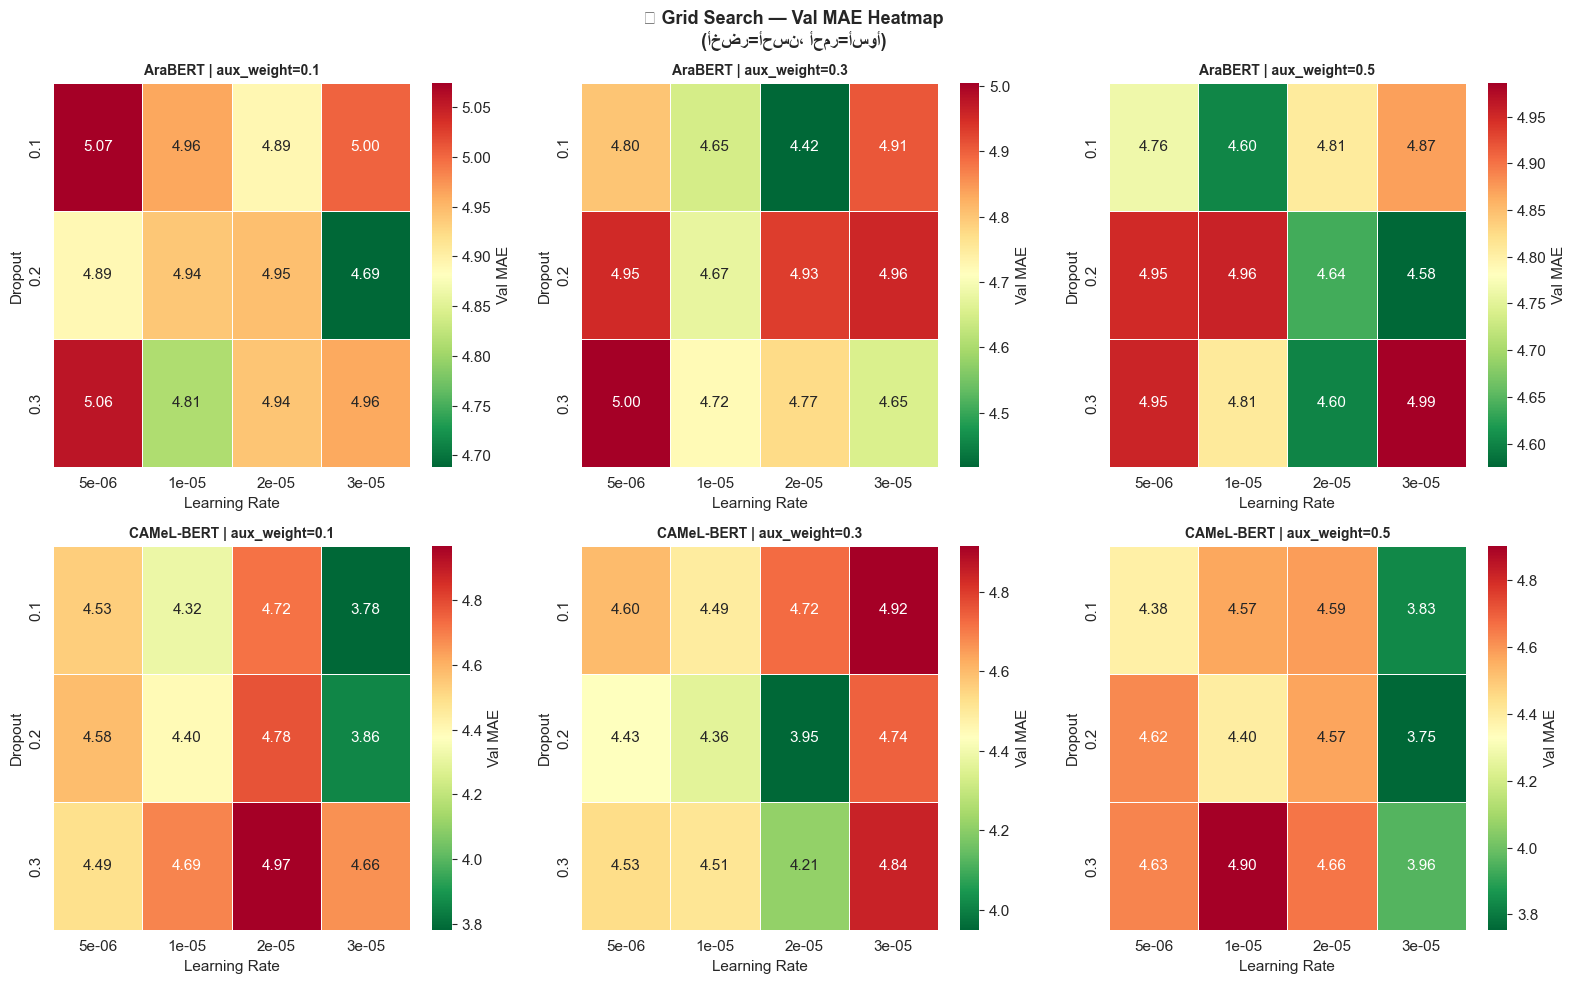

In [21]:
# ── Heatmaps: MAE لكل combination ─────────────────────
fig, axes = plt.subplots(len(MODELS), len(GRID['aux_weight']),
                          figsize=(16, 5*len(MODELS)))
fig.suptitle('🔍 Grid Search — Val MAE Heatmap\n(أخضر=أحسن، أحمر=أسوأ)',
             fontsize=13, fontweight='bold')

for row_i, (model_name, results) in enumerate(grid_results.items()):
    gdf = pd.DataFrame(results)
    for col_i, aux_w in enumerate(GRID['aux_weight']):
        ax    = axes[row_i, col_i] if len(MODELS)>1 else axes[col_i]
        sub   = gdf[gdf['aux_weight']==aux_w]
        pivot = sub.pivot_table(index='dropout', columns='lr', values='val_mae')
        # Format column names
        pivot.columns = [f'{c:.0e}' for c in pivot.columns]
        sns.heatmap(pivot, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.2f',
                    linewidths=.5, linecolor='white',
                    cbar_kws={'label':'Val MAE'})
        ax.set_title(f'{model_name} | aux_weight={aux_w}', fontsize=10)
        ax.set_xlabel('Learning Rate')
        ax.set_ylabel('Dropout')

plt.tight_layout()
plt.savefig('gs_01_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

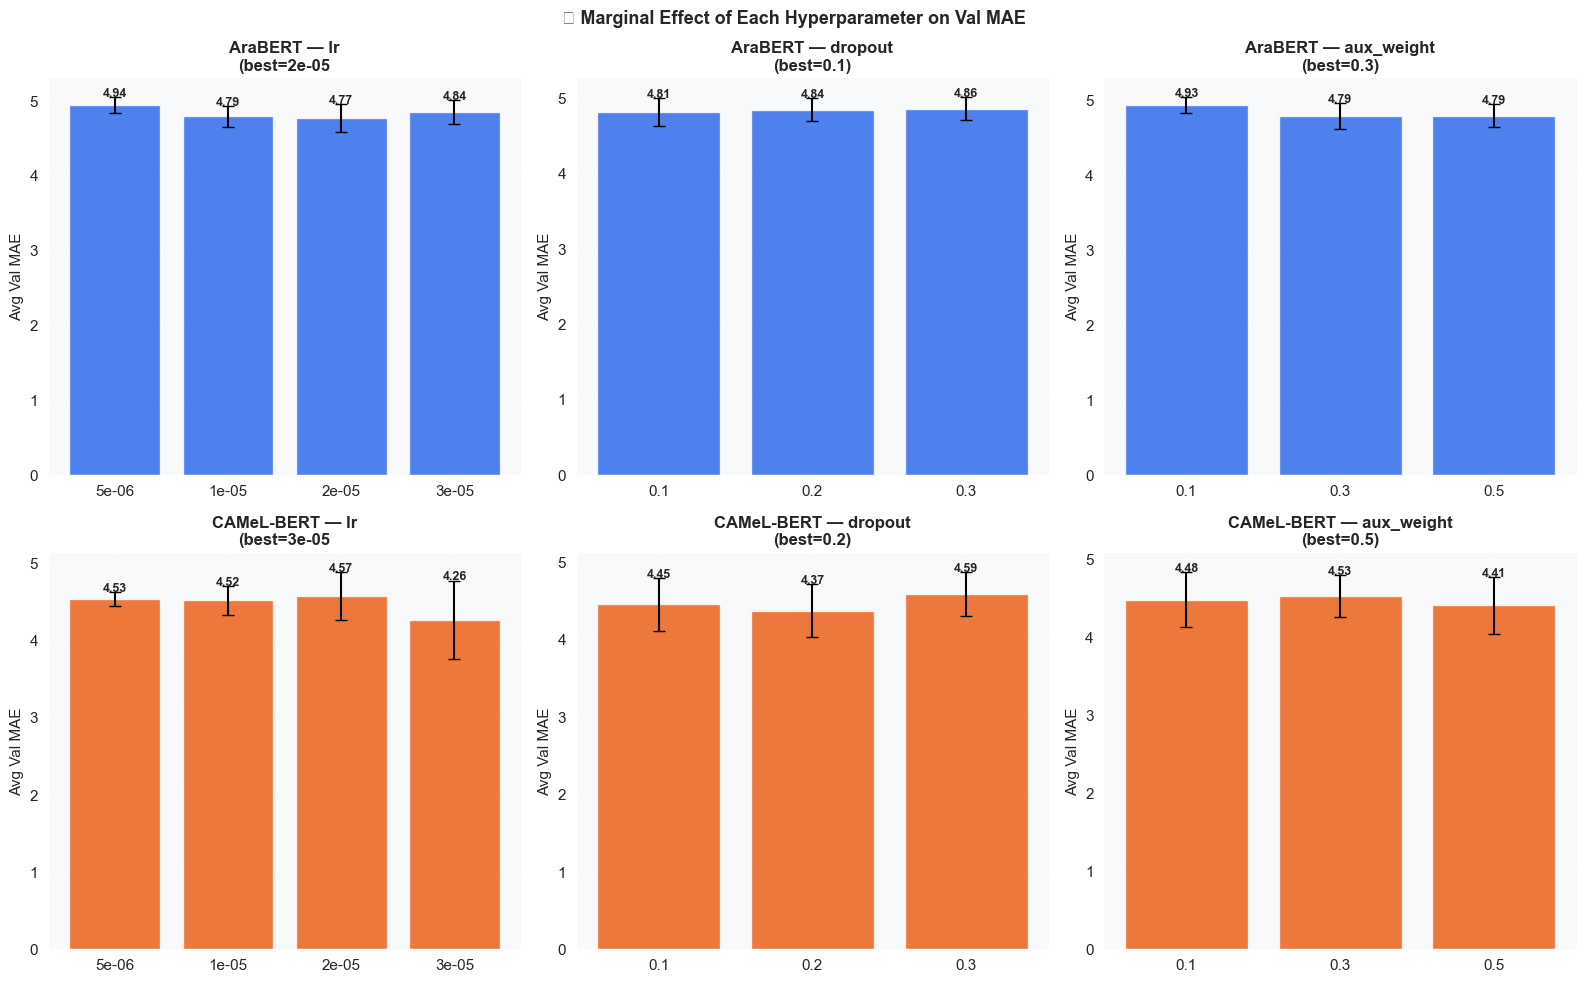

In [22]:
# ── Marginal effect of each hyperparameter ─────────────
fig, axes = plt.subplots(len(MODELS), 3, figsize=(16, 5*len(MODELS)))
fig.suptitle('📊 Marginal Effect of Each Hyperparameter on Val MAE',
             fontsize=13, fontweight='bold')

for row_i, (model_name, results) in enumerate(grid_results.items()):
    gdf = pd.DataFrame(results)
    for col_i, (param, vals) in enumerate(GRID.items()):
        ax = axes[row_i, col_i] if len(MODELS)>1 else axes[col_i]
        # لكل قيمة نحسب متوسط الـ MAE على كل الـ combinations التانية
        means = [gdf[gdf[param]==v]['val_mae'].mean() for v in vals]
        stds  = [gdf[gdf[param]==v]['val_mae'].std()  for v in vals]
        x     = range(len(vals))
        ax.bar(x, means, color=CLRS[model_name], alpha=0.8)
        ax.errorbar(x, means, yerr=stds, fmt='none', color='black', capsize=4)
        best_v = vals[int(np.argmin(means))]
        ax.set_xticks(x)
        ax.set_xticklabels([f'{v:.0e}' if param=='lr' else str(v) for v in vals])
        ax.set_title(f'{model_name} — {param}\n(best={best_v:.0e}' if param=='lr'
                     else f'{model_name} — {param}\n(best={best_v})')
        ax.set_ylabel('Avg Val MAE')
        for xi, (m, s) in enumerate(zip(means, stds)):
            ax.text(xi, m+s+.01, f'{m:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('gs_02_marginal_effects.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── Top 10 overall ────────────────────────────────────
all_rows = []
for mn, results in grid_results.items():
    for r in results:
        all_rows.append({'Model':mn, **r})
all_gdf = pd.DataFrame(all_rows)

print('🏅 Top 10 Combinations (بجميع الموديلات):')
top10 = all_gdf.nsmallest(10,'val_mae')[['Model','lr','dropout','aux_weight','val_mae','val_acc','val_spearman']].copy()
top10['val_acc'] = (top10['val_acc']*100).round(1).astype(str)+'%'
top10['lr']      = top10['lr'].apply(lambda x: f'{x:.0e}')
top10['val_mae'] = top10['val_mae'].round(2)
top10['val_spearman'] = top10['val_spearman'].round(3)
display(top10.style.hide(axis='index')
        .background_gradient(subset=['val_mae'],cmap='RdYlGn_r')
        .set_caption('🏅 Top 10 Grid Search Results')
        .set_table_styles([{'selector':'caption','props':[('font-weight','bold'),('font-size','14px')]}]))

🏅 Top 10 Combinations (بجميع الموديلات):


Model,lr,dropout,aux_weight,val_mae,val_acc,val_spearman
CAMeL-BERT,3e-05,0.200000,0.500000,3.750000,89.8%,0.859000
CAMeL-BERT,3e-05,0.100000,0.100000,3.780000,89.3%,0.844000
CAMeL-BERT,3e-05,0.100000,0.500000,3.830000,90.2%,0.853000
CAMeL-BERT,3e-05,0.200000,0.100000,3.860000,87.8%,0.856000
CAMeL-BERT,2e-05,0.200000,0.300000,3.950000,86.0%,0.849000
CAMeL-BERT,3e-05,0.300000,0.500000,3.960000,88.5%,0.840000
CAMeL-BERT,2e-05,0.300000,0.300000,4.210000,79.9%,0.815000
CAMeL-BERT,1e-05,0.100000,0.100000,4.320000,80.3%,0.821000
CAMeL-BERT,1e-05,0.200000,0.300000,4.360000,82.5%,0.810000
CAMeL-BERT,5e-06,0.100000,0.500000,4.380000,83.4%,0.812000


---
## 7️⃣ 🚀 Full Training بأحسن Params

In [24]:
print('🎯 Best params found:')
for mn, p in best_params.items():
    print(f'   {mn}: lr={p["lr"]:.0e}  dropout={p["dropout"]}  aux_weight={p["aux_weight"]}')

final_models  = {}
final_history = {}

def build_layerwise_optimizer(model, base_lr, head_lr, weight_decay, lr_decay):
    no_decay   = ['bias','LayerNorm.weight']
    num_layers = len(model.bert.encoder.layer)
    params     = []
    emb_lr     = base_lr * (lr_decay ** num_layers)
    params += [
        {'params':[p for n,p in model.bert.embeddings.named_parameters() if not any(nd in n for nd in no_decay)],'lr':emb_lr,'weight_decay':weight_decay},
        {'params':[p for n,p in model.bert.embeddings.named_parameters() if     any(nd in n for nd in no_decay)],'lr':emb_lr,'weight_decay':0.0},
    ]
    for i, layer in enumerate(model.bert.encoder.layer):
        layer_lr = base_lr * (lr_decay ** (num_layers-i))
        params  += [
            {'params':[p for n,p in layer.named_parameters() if not any(nd in n for nd in no_decay)],'lr':layer_lr,'weight_decay':weight_decay},
            {'params':[p for n,p in layer.named_parameters() if     any(nd in n for nd in no_decay)],'lr':layer_lr,'weight_decay':0.0},
        ]
    params += [
        {'params':list(model.shared.parameters())+list(model.reg_head.parameters())+list(model.cls_head.parameters())+list(model.att_pool.parameters()),
         'lr':head_lr,'weight_decay':weight_decay},
    ]
    return torch.optim.AdamW(params)

for model_name, model_path in MODELS.items():
    p   = best_params[model_name]
    tok = tokenizers[model_name]
    print(f'\n{"="*60}\n🚀 Full Training: {model_name}\n   {p}\n{"="*60}')

    train_ds = CVDatasetSliding(train_df, tok)
    val_ds   = CVDatasetSliding(val_df,   tok)
    train_dl = DataLoader(train_ds, batch_size=FIXED['batch_size'], shuffle=True, collate_fn=collate_fn)
    val_dl   = DataLoader(val_ds,   batch_size=FIXED['batch_size'], collate_fn=collate_fn)

    model     = CVRegressor(model_path, dropout=p['dropout']).to(device)
    criterion = DualLoss(class_weights_tensor, aux_weight=p['aux_weight'])
    save_path = SAVE_DIR / f'{model_name.replace("-","_")}_best.pt'

    # Phase 1: Freeze
    freeze_eps = FIXED['freeze_epochs']
    for param in model.bert.parameters(): param.requires_grad = False
    opt_frz = torch.optim.AdamW(
        list(model.shared.parameters())+list(model.reg_head.parameters())+
        list(model.cls_head.parameters())+list(model.att_pool.parameters()),
        lr=FIXED['head_lr'], weight_decay=FIXED['weight_decay']
    )
    sched_frz = get_linear_schedule_with_warmup(opt_frz, 0, len(train_dl)*freeze_eps)
    history, best_mae = [], float('inf')

    print(f'  🧊 Phase 1: Freeze ({freeze_eps} epochs)')
    for epoch in range(freeze_eps):
        tr = run_epoch(model,train_dl,opt_frz,criterion,sched_frz,train=True,max_grad_norm=FIXED['max_grad_norm'])
        vl = run_epoch(model,val_dl,  opt_frz,criterion,train=False)
        history.append({'t_loss':tr['loss'],'v_loss':vl['loss'],'t_mae':tr['mae'],
                         'v_mae':vl['mae'],'t_acc':tr['acc'],'v_acc':vl['acc'],'phase':'frozen'})
        print(f'  🧊 Ep{epoch+1:02d}  loss={vl["loss"]:.4f}  mae={vl["mae"]:.2f}  acc={vl["acc"]*100:.1f}%')
        if vl['mae'] < best_mae:
            best_mae=vl['mae']
            torch.save({'model_state':model.state_dict(),'model_name':model_name,'model_path':model_path,
                        'best_params':p,'fixed_params':FIXED,'thresholds':(T1,T2,T3),
                        'score_range':(SCORE_MIN,SCORE_MAX),'best_epoch':epoch+1,'best_mae':best_mae}, save_path)

    # Phase 2: Unfreeze
    rem = FULL_EPOCHS - freeze_eps
    for param in model.bert.parameters(): param.requires_grad = True
    optimizer    = build_layerwise_optimizer(model, p['lr'], FIXED['head_lr'],
                                              FIXED['weight_decay'], FIXED['lr_decay'])
    total_steps  = len(train_dl)*rem
    warmup_steps = int(total_steps*FIXED['warmup_ratio'])
    # ✅ Cosine بدل Linear — كان فيه noise واضح في الـ epochs الأخيرة (loss بيقفز لأعلى
    # وlr بيوصل صفر فجأة)؛ الـ cosine decay بيبقى أنعم في الانحدار النهائي
    scheduler    = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    patience_ctr = 0

    print(f'  🔥 Phase 2: Unfreeze ({rem} epochs)')
    for epoch in range(rem):
        tr = run_epoch(model,train_dl,optimizer,criterion,scheduler,train=True,max_grad_norm=FIXED['max_grad_norm'])
        vl = run_epoch(model,val_dl,  optimizer,criterion,train=False)
        cur_lr = optimizer.param_groups[-1]['lr']
        history.append({'t_loss':tr['loss'],'v_loss':vl['loss'],'t_mae':tr['mae'],
                         'v_mae':vl['mae'],'t_acc':tr['acc'],'v_acc':vl['acc'],'phase':'unfrozen'})
        flag = '💾' if vl['mae'] < best_mae else '  '
        print(f'  {flag} 🔥 Ep{epoch+freeze_eps+1:02d}  '
              f'loss={vl["loss"]:.4f}  mae={vl["mae"]:.2f}  '
              f'acc={vl["acc"]*100:.1f}%  lr={cur_lr:.2e}')
        if vl['mae'] < best_mae:
            best_mae=vl['mae']; patience_ctr=0
            torch.save({'model_state':model.state_dict(),'model_name':model_name,'model_path':model_path,
                        'best_params':p,'fixed_params':FIXED,'thresholds':(T1,T2,T3),
                        'score_range':(SCORE_MIN,SCORE_MAX),'best_epoch':epoch+freeze_eps+1,'best_mae':best_mae}, save_path)
        else:
            patience_ctr+=1
            if patience_ctr>=PATIENCE: print(f'  ⏹️  Early stopping'); break

    print(f'  ✅ Best MAE={best_mae:.2f}')
    final_models[model_name]=model; final_history[model_name]=history

print('\n✅ Full Training complete!')

🎯 Best params found:
   AraBERT: lr=2e-05  dropout=0.1  aux_weight=0.3
   CAMeL-BERT: lr=3e-05  dropout=0.2  aux_weight=0.5

🚀 Full Training: AraBERT
   {'lr': np.float64(2e-05), 'dropout': np.float64(0.1), 'aux_weight': np.float64(0.3)}


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3964.05it/s]
[transformers] BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  🧊 Phase 1: Freeze (2 epochs)
  🧊 Ep01  loss=0.2176  mae=6.52  acc=42.5%
  🧊 Ep02  loss=0.2011  mae=6.46  acc=42.1%
  🔥 Phase 2: Unfreeze (8 epochs)
  💾 🔥 Ep03  loss=0.1078  mae=5.62  acc=58.4%  lr=9.98e-05
  💾 🔥 Ep04  loss=0.0959  mae=4.98  acc=61.8%  lr=9.33e-05
  💾 🔥 Ep05  loss=0.0852  mae=3.72  acc=75.5%  lr=7.87e-05
  💾 🔥 Ep06  loss=0.0990  mae=3.29  acc=84.6%  lr=5.87e-05
     🔥 Ep07  loss=0.1203  mae=3.74  acc=78.5%  lr=3.71e-05
     🔥 Ep08  loss=0.1496  mae=3.55  acc=80.6%  lr=1.79e-05
     🔥 Ep09  loss=0.1412  mae=3.35  acc=85.0%  lr=4.68e-06
  ⏹️  Early stopping
  ✅ Best MAE=3.29

🚀 Full Training: CAMeL-BERT
   {'lr': np.float64(3e-05), 'dropout': np.float64(0.2), 'aux_weight': np.float64(0.5)}


Loading weights: 100%|██████████| 199/199 [00:00<?, ?it/s]
[transformers] BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-mix
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  🧊 Phase 1: Freeze (2 epochs)
  🧊 Ep01  loss=0.2984  mae=5.57  acc=63.2%
  🧊 Ep02  loss=0.2751  mae=5.42  acc=65.8%
  🔥 Phase 2: Unfreeze (8 epochs)
  💾 🔥 Ep03  loss=0.1519  mae=4.65  acc=86.0%  lr=9.98e-05
  💾 🔥 Ep04  loss=0.1189  mae=4.04  acc=87.0%  lr=9.33e-05
     🔥 Ep05  loss=0.1550  mae=4.12  acc=88.4%  lr=7.87e-05
     🔥 Ep06  loss=0.2026  mae=4.14  acc=88.2%  lr=5.87e-05
     🔥 Ep07  loss=0.2397  mae=4.13  acc=89.5%  lr=3.71e-05
  ⏹️  Early stopping
  ✅ Best MAE=4.04

✅ Full Training complete!


---
## 8️⃣ Final Evaluation + Ensemble

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, r2_score

eval_results = {}
for model_name, model_path in MODELS.items():
    ckpt  = torch.load(SAVE_DIR/f'{model_name.replace("-","_")}_best.pt',
                       map_location=device, weights_only=False)
    p     = ckpt['best_params']
    model = CVRegressor(model_path, dropout=p['dropout']).to(device)
    model.load_state_dict(ckpt['model_state'])
    final_models[model_name] = model

    criterion = DualLoss(class_weights_tensor, aux_weight=p['aux_weight'])
    test_dl   = DataLoader(CVDatasetSliding(test_df,tokenizers[model_name]),
                           batch_size=8, collate_fn=collate_fn)
    res = run_epoch(model,test_dl,None,criterion,train=False)
    res['r2']       = r2_score(res['trues'],res['preds'])
    res['spearman'] = spearmanr(res['trues'],res['preds'])[0]
    res['pred_classes'] = [score_to_class(p) for p in res['preds']]
    res['true_classes'] = [score_to_class(s) for s in res['trues']]
    eval_results[model_name] = res
    print(f'📊 {model_name:<12}  MAE={res["mae"]:.2f}  Acc={res["acc"]*100:.1f}%  R²={res["r2"]:.3f}')
    print(f'   Best params: lr={p["lr"]:.0e}  dropout={p["dropout"]}  aux={p["aux_weight"]}')
    print(classification_report(res['true_classes'],res['pred_classes'],
                                 target_names=CLASS_NAMES,labels=CLASS_LABELS))

# Ensemble
maes    = {mn:eval_results[mn]['mae'] for mn in MODELS}
inv_mae = {mn:1/v for mn,v in maes.items()}
total   = sum(inv_mae.values())
weights = {mn:v/total for mn,v in inv_mae.items()}
ens_preds  = sum(weights[mn]*np.array(eval_results[mn]['preds']) for mn in MODELS)
true_scores= eval_results[list(MODELS.keys())[0]]['trues']
ens_cls    = [score_to_class(p) for p in ens_preds]
true_cls   = [score_to_class(s) for s in true_scores]
eval_results['Ensemble'] = {
    'mae' :mean_absolute_error(true_scores,ens_preds),
    'rmse':np.sqrt(mean_squared_error(true_scores,ens_preds)),
    'r2'  :r2_score(true_scores,ens_preds),
    'spearman':spearmanr(true_scores,ens_preds)[0],
    'acc' :sum(p==t for p,t in zip(ens_cls,true_cls))/len(true_cls),
    'preds':ens_preds.tolist(),'trues':true_scores,
    'pred_classes':ens_cls,'true_classes':true_cls
}

winner = min(eval_results, key=lambda x: eval_results[x]['mae'])
print(f'\n🔀 Ensemble  MAE={eval_results["Ensemble"]["mae"]:.2f}  Acc={eval_results["Ensemble"]["acc"]*100:.1f}%')
print(f'🏆 Winner: {winner}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4239.73it/s]
[transformers] BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📊 AraBERT       MAE=2.85  Acc=87.3%  R²=0.818
   Best params: lr=2e-05  dropout=0.1  aux=0.3
              precision    recall  f1-score   support

        ضعيف       0.99      0.97      0.98       188
       متوسط       0.91      0.72      0.81       172
         جيد       0.79      0.99      0.88       193
       ممتاز       0.83      0.78      0.80       169

    accuracy                           0.87       722
   macro avg       0.88      0.87      0.87       722
weighted avg       0.88      0.87      0.87       722



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16679.65it/s]
[transformers] BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-mix
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📊 CAMeL-BERT    MAE=3.82  Acc=89.6%  R²=0.815
   Best params: lr=3e-05  dropout=0.2  aux=0.5
              precision    recall  f1-score   support

        ضعيف       1.00      0.97      0.99       188
       متوسط       0.93      0.74      0.83       172
         جيد       0.80      1.00      0.89       193
       ممتاز       0.89      0.85      0.87       169

    accuracy                           0.90       722
   macro avg       0.91      0.89      0.89       722
weighted avg       0.90      0.90      0.89       722


🔀 Ensemble  MAE=3.12  Acc=87.7%
🏆 Winner: AraBERT


Model,MAE,RMSE,R²,Spearman,Accuracy,
AraBERT,2.850000,0.000000,0.817600,0.874000,87.3%,🏆
CAMeL-BERT,3.820000,0.000000,0.814800,0.872900,89.6%,
Ensemble,3.120000,5.360000,0.838100,0.896700,87.7%,🔀


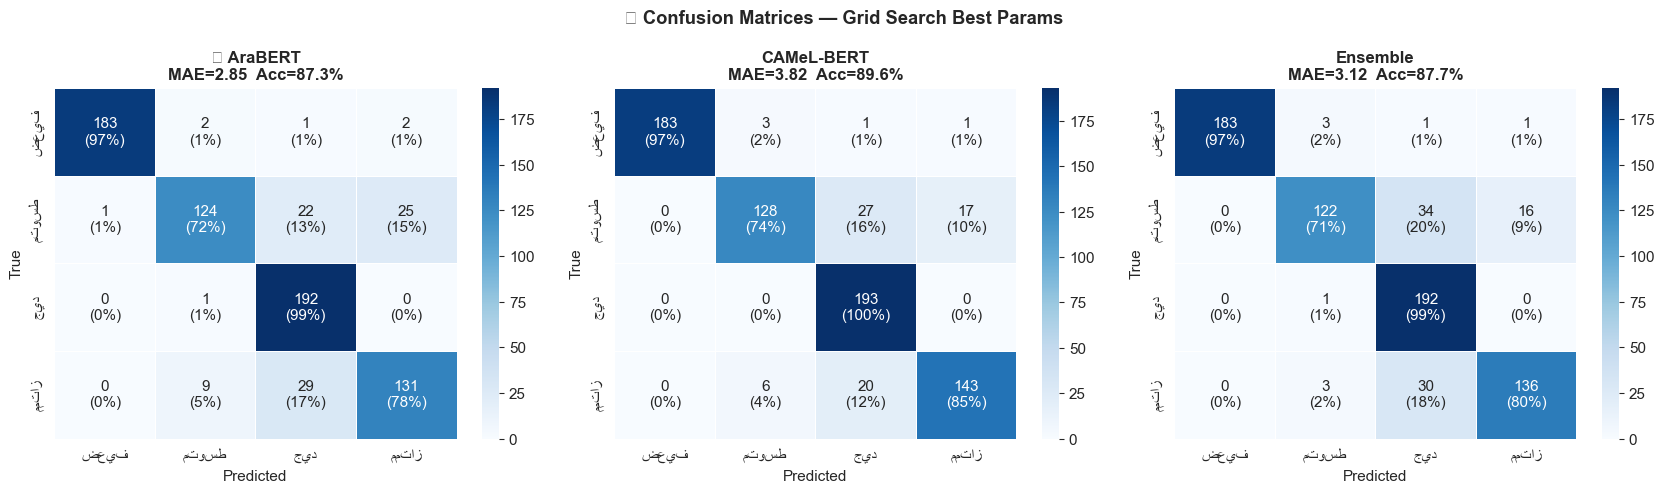

In [26]:
# Summary table
rows=[{'Model':mn,'MAE':round(r['mae'],2),'RMSE':round(r.get('rmse',0),2),
       'R²':round(r['r2'],4),'Spearman':round(r['spearman'],4),
       'Accuracy':f"{r['acc']*100:.1f}%",
       '':('🏆' if mn==winner else ('🔀' if mn=='Ensemble' else ''))}
      for mn,r in eval_results.items()]
display(pd.DataFrame(rows).style.hide(axis='index')
        .highlight_min(subset=['MAE','RMSE'],color='#DCFCE7')
        .highlight_max(subset=['R²','Spearman'],color='#DCFCE7')
        .set_caption('📊 Final Results')
        .set_table_styles([{'selector':'caption','props':[('font-weight','bold'),('font-size','14px')]}]))

# Confusion matrices
fig, axes = plt.subplots(1,3,figsize=(17,5))
fig.suptitle('📊 Confusion Matrices — Grid Search Best Params', fontweight='bold')
for ax, mn in zip(axes, list(eval_results.keys())):
    res=eval_results[mn]
    cm=confusion_matrix(res['true_classes'],res['pred_classes'],labels=CLASS_LABELS)
    pct=cm.astype(float)/cm.sum(axis=1,keepdims=True)*100
    ann=np.array([[f'{v}\n({p:.0f}%)' for v,p in zip(rv,rp)] for rv,rp in zip(cm,pct)])
    sns.heatmap(cm,annot=ann,fmt='',ax=ax,cmap='Blues',
                xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,
                linewidths=.5,linecolor='white')
    ax.set_title(('🏆 ' if mn==winner else '')+f'{mn}\nMAE={res["mae"]:.2f}  Acc={res["acc"]*100:.1f}%')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.savefig('gs_03_final_eval.png',dpi=150,bbox_inches='tight'); plt.show()

In [27]:
# Save config with best params
config = {
    'thresholds'      : {'T1':T1,'T2':T2,'T3':T3},
    'score_range'     : {'min':SCORE_MIN,'max':SCORE_MAX},
    'class_names'     : CLASS_NAMES,'class_labels':CLASS_LABELS,
    'winner_model'    : winner,'models':MODELS,
    'best_params'     : {mn:{**p,'lr':str(p['lr'])} for mn,p in best_params.items()},
    'fixed_params'    : {**FIXED,'head_lr':str(FIXED['head_lr'])},
    'ensemble_weights': {mn:round(w,4) for mn,w in weights.items()},
    'eval_summary'    : {mn:{'mae':round(r['mae'],4),'acc':round(r['acc'],4),
                              'r2':round(r['r2'],4),'spearman':round(r['spearman'],4)}
                         for mn,r in eval_results.items()},
    'grid_search'     : {
        'params_searched': GRID,
        'grid_epochs'    : GRID_EPOCHS,
        'total_combos'   : len(all_combos)
    }
}
with open(SAVE_DIR/'config.json','w',encoding='utf-8') as f:
    json.dump(config,f,ensure_ascii=False,indent=2)
print('✅ config.json saved (with grid search best params)')
print(f'\n🎉 Done! Winner:{winner}  '
      f'MAE={eval_results[winner]["mae"]:.2f}  '
      f'Acc={eval_results[winner]["acc"]*100:.1f}%')

✅ config.json saved (with grid search best params)

🎉 Done! Winner:AraBERT  MAE=2.85  Acc=87.3%
